📦 Memuat dataset...
Shape dataset  : (25999, 19)
Kolom          : ['DataId', 'who_region', 'iso3', 'country_name', 'city', 'year', 'pm10_concentration', 'pm25_concentration', 'no2_concentration', 'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'type_of_stations', 'number_of_stations', 'population', 'latitude', 'longitude', 'who_ms', 'Air_quality_category']

=== MISSING VALUES ===
                    Jumlah NaN  Persentase (%)
pm10_concentration        6988            26.9
pm25_concentration       12983            49.9
no2_concentration         8817            33.9
pm10_tempcov             11904            45.8
pm25_tempcov             16367            63.0
no2_tempcov              11296            43.4
population               10315            39.7

=== STATISTIK PM2.5 ===
count    13016.000000
mean        19.817682
std         18.196983
min          1.000000
25%          8.900000
50%         13.293500
75%         23.605500
max        436.440000

Distribusi Kategori Kualitas Udara:
Air_

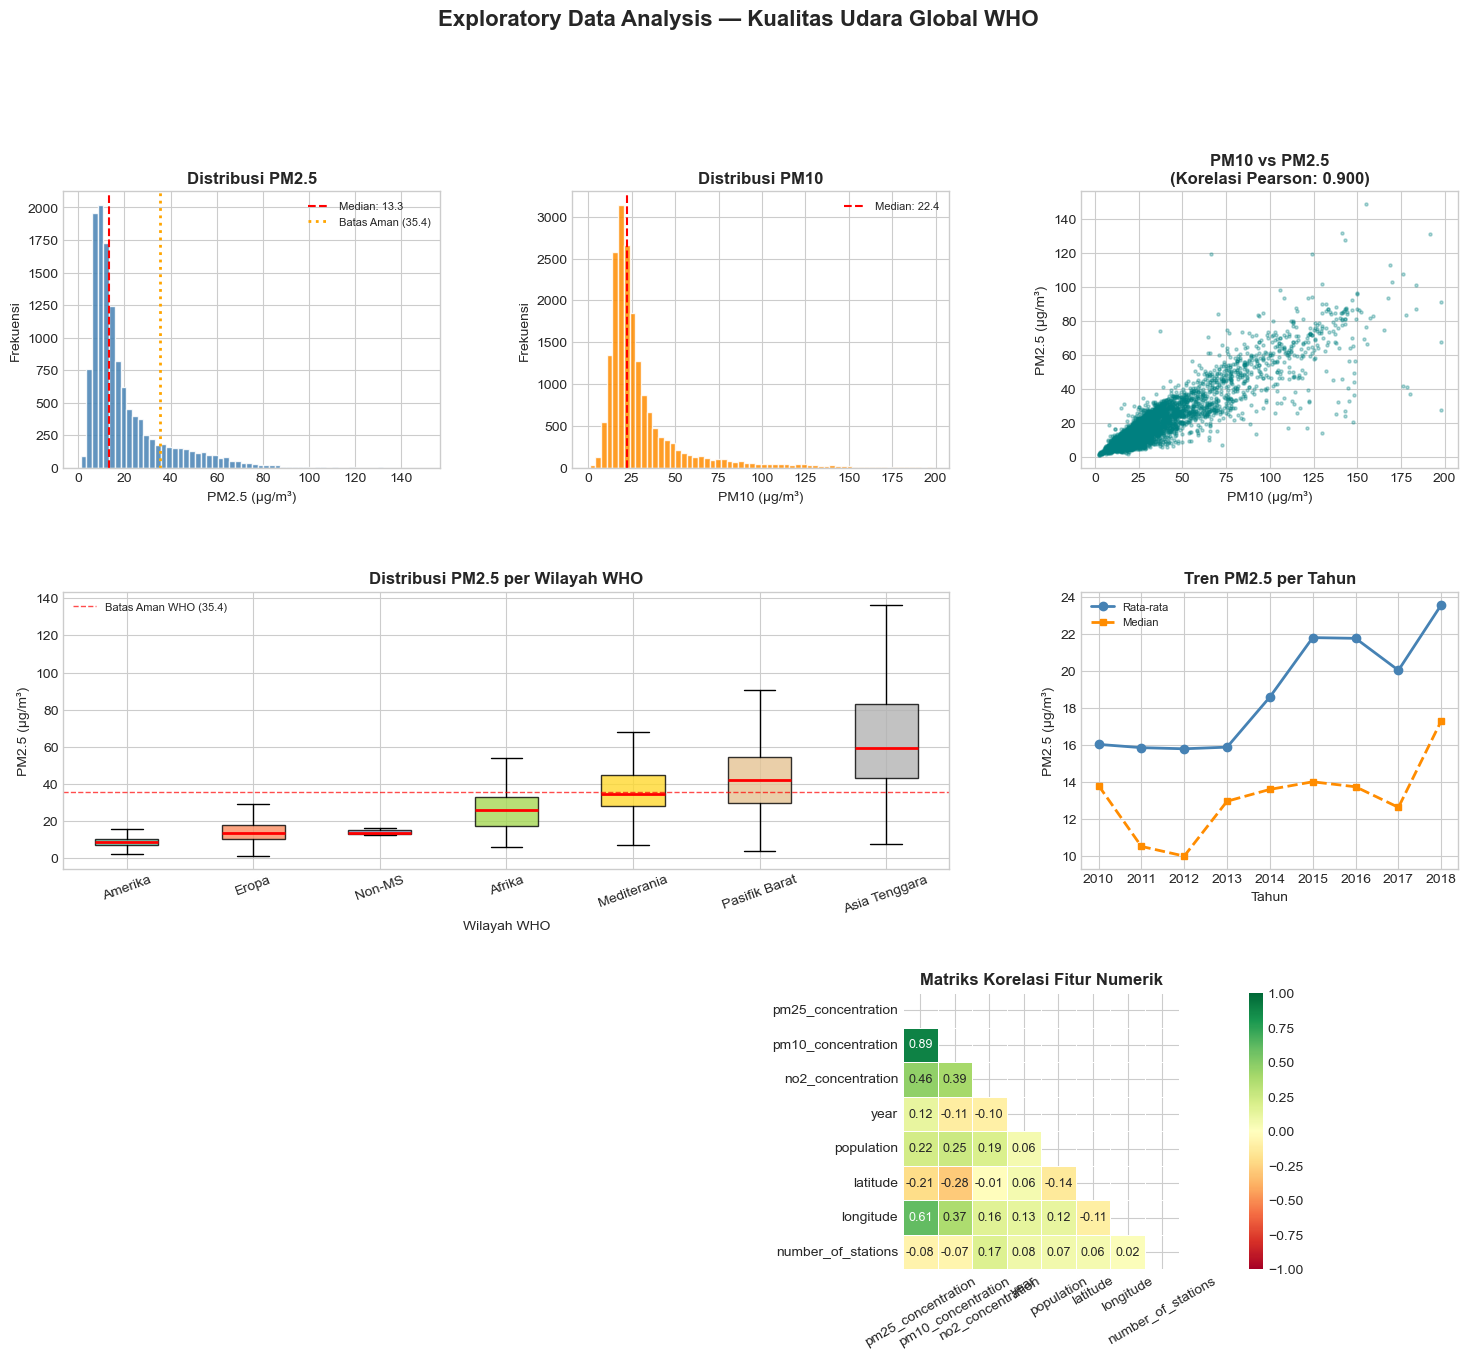


✅ EDA selesai. Gambar disimpan: 'eda_visualisasi.png'


In [23]:
# ===================================================================
# CELL 1: IMPORT LIBRARY & EXPLORATORY DATA ANALYSIS (EDA)
# ===================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ------------------------------------------------------------------
# 1.1 Muat & Konversi Dataset
# ------------------------------------------------------------------
print("📦 Memuat dataset...")
df_raw = pd.read_csv("action2024/train.csv")

# Kolom yang tersimpan sebagai string padahal seharusnya numerik
COLS_NUMERIC = [
    'pm25_concentration', 'pm10_concentration', 'no2_concentration',
    'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'population'
]
for col in COLS_NUMERIC:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape dataset  : {df_raw.shape}")
print(f"Kolom          : {df_raw.columns.tolist()}\n")

# ------------------------------------------------------------------
# 1.2 Laporan Missing Value
# ------------------------------------------------------------------
null_info = pd.DataFrame({
    'Jumlah NaN'    : df_raw.isnull().sum(),
    'Persentase (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
})
print("=== MISSING VALUES ===")
print(null_info[null_info['Jumlah NaN'] > 0].to_string())

# ------------------------------------------------------------------
# 1.3 Statistik Deskriptif Target
# ------------------------------------------------------------------
print("\n=== STATISTIK PM2.5 ===")
print(df_raw['pm25_concentration'].describe().to_string())
print(f"\nDistribusi Kategori Kualitas Udara:")
print(df_raw['Air_quality_category'].value_counts().to_string())

# ------------------------------------------------------------------
# 1.4 Visualisasi EDA (6 subplot)
# ------------------------------------------------------------------
REGION_LABEL = {
    '1_Afr': 'Afrika', '2_Amr': 'Amerika', '3_Sear': 'Asia Tenggara',
    '4_Eur': 'Eropa',  '5_Emr': 'Mediterania', '6_Wpr': 'Pasifik Barat',
    '7_NonMS': 'Non-MS'
}
df_raw['region_label'] = df_raw['who_region'].map(REGION_LABEL)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Exploratory Data Analysis — Kualitas Udara Global WHO',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Distribusi PM2.5
ax1 = fig.add_subplot(gs[0, 0])
pm25_v = df_raw['pm25_concentration'].dropna()
ax1.hist(pm25_v[pm25_v < 150], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(pm25_v.median(), color='red', ls='--', lw=1.5, label=f'Median: {pm25_v.median():.1f}')
ax1.axvline(35.4, color='orange', ls=':', lw=2, label='Batas Aman (35.4)')
ax1.set_title('Distribusi PM2.5', fontweight='bold')
ax1.set_xlabel('PM2.5 (µg/m³)'); ax1.set_ylabel('Frekuensi')
ax1.legend(fontsize=8)

# Plot 2: Distribusi PM10
ax2 = fig.add_subplot(gs[0, 1])
pm10_v = df_raw['pm10_concentration'].dropna()
ax2.hist(pm10_v[pm10_v < 200], bins=60, color='darkorange', edgecolor='white', alpha=0.85)
ax2.axvline(pm10_v.median(), color='red', ls='--', lw=1.5, label=f'Median: {pm10_v.median():.1f}')
ax2.set_title('Distribusi PM10', fontweight='bold')
ax2.set_xlabel('PM10 (µg/m³)'); ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=8)

# Plot 3: Scatter PM10 vs PM2.5 (korelasi terkuat)
ax3 = fig.add_subplot(gs[0, 2])
sc = df_raw.dropna(subset=['pm10_concentration', 'pm25_concentration'])
sc = sc[(sc['pm10_concentration'] < 200) & (sc['pm25_concentration'] < 150)]
corr_val = sc['pm10_concentration'].corr(sc['pm25_concentration'])
ax3.scatter(sc['pm10_concentration'], sc['pm25_concentration'],
            alpha=0.3, s=5, color='teal')
ax3.set_title(f'PM10 vs PM2.5\n(Korelasi Pearson: {corr_val:.3f})', fontweight='bold')
ax3.set_xlabel('PM10 (µg/m³)'); ax3.set_ylabel('PM2.5 (µg/m³)')

# Plot 4: Boxplot PM2.5 per Wilayah WHO
ax4 = fig.add_subplot(gs[1, :2])
plot_df = df_raw.dropna(subset=['pm25_concentration', 'region_label'])
plot_df = plot_df[plot_df['pm25_concentration'] < 150]
order = plot_df.groupby('region_label')['pm25_concentration'].median().sort_values().index.tolist()
bp_data = [plot_df[plot_df['region_label'] == r]['pm25_concentration'].values for r in order]
bp = ax4.boxplot(bp_data, labels=order, patch_artist=True, showfliers=False,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(order)))):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax4.axhline(35.4, color='red', ls='--', lw=1, alpha=0.7, label='Batas Aman WHO (35.4)')
ax4.set_title('Distribusi PM2.5 per Wilayah WHO', fontweight='bold')
ax4.set_xlabel('Wilayah WHO'); ax4.set_ylabel('PM2.5 (µg/m³)')
ax4.tick_params(axis='x', rotation=20); ax4.legend(fontsize=8)

# Plot 5: Tren PM2.5 per Tahun
ax5 = fig.add_subplot(gs[1, 2])
yr = df_raw.dropna(subset=['pm25_concentration']).groupby('year')['pm25_concentration'].agg(['mean', 'median'])
ax5.plot(yr.index, yr['mean'],   'o-', color='steelblue',  lw=2, ms=6, label='Rata-rata')
ax5.plot(yr.index, yr['median'], 's--', color='darkorange', lw=2, ms=5, label='Median')
ax5.set_title('Tren PM2.5 per Tahun', fontweight='bold')
ax5.set_xlabel('Tahun'); ax5.set_ylabel('PM2.5 (µg/m³)')
ax5.legend(fontsize=8)

# Plot 6: Heatmap Korelasi
ax6 = fig.add_subplot(gs[2, :])
corr_cols = ['pm25_concentration', 'pm10_concentration', 'no2_concentration',
             'year', 'population', 'latitude', 'longitude', 'number_of_stations']
corr_m = df_raw[corr_cols].corr()
mask  = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax6, square=True,
            annot_kws={'size': 9}, linewidths=0.5)
ax6.set_title('Matriks Korelasi Fitur Numerik', fontweight='bold')
ax6.tick_params(axis='x', rotation=30); ax6.tick_params(axis='y', rotation=0)

plt.savefig('eda_visualisasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA selesai. Gambar disimpan: 'eda_visualisasi.png'")

Jumlah sampel siap latih : 13,016
Jumlah fitur             : 9
  Numerik   : ['year', 'latitude', 'longitude', 'pm10_concentration', 'no2_concentration', 'number_of_stations', 'who_ms', 'population']
  Kategorikal: ['who_region']

🔬 PERBANDINGAN MODEL — 5-Fold Cross Validation
Model                       CV R²     ±Std      CV RMSE     CV MAE
--------------------------------------------------------------------
Linear Regression          0.6522   0.0385      10.7240     5.8856
Ridge Regression           0.6522   0.0386      10.7234     5.8810
Decision Tree              0.7746   0.0692       8.5595     3.5640
Random Forest              0.8718   0.0521       6.4342     2.4163
Gradient Boosting          0.8450   0.0653       7.0482     2.8309

✅ Model Terbaik: Random Forest (R² = 0.8718)


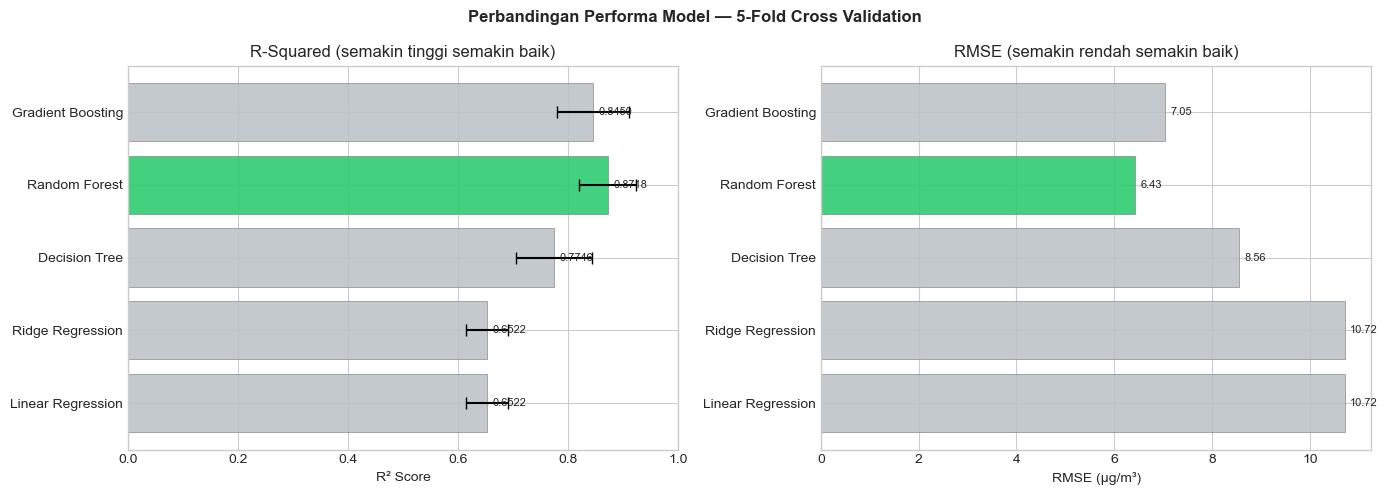

✅ Gambar perbandingan disimpan: 'perbandingan_model.png'


In [24]:
# ===================================================================
# CELL 2: FEATURE ENGINEERING & PERBANDINGAN MODEL (Cross-Validation)
# ===================================================================
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# ------------------------------------------------------------------
# 2.1 Tentukan Fitur & Target
# ------------------------------------------------------------------
TARGET = 'pm25_concentration'

# Fitur numerik — pm10_concentration adalah fitur TERPENTING (korelasi 0.886)
FITUR_NUMERIK = [
    'year',
    'latitude',
    'longitude',
    'pm10_concentration',    # ⭐ Korelasi 0.886 — fitur paling prediktif
    'no2_concentration',     # ⭐ Polutan terkait, menambah konteks udara
    'number_of_stations',    # Kualitas pengukuran
    'who_ms',                # Status anggota WHO
    'population',            # Ukuran area kota
]

FITUR_KATEGORIKAL = ['who_region']  # Nilai: 1_Afr, 2_Amr, 3_Sear, 4_Eur, 5_Emr, 6_Wpr, 7_NonMS
SEMUA_FITUR = FITUR_NUMERIK + FITUR_KATEGORIKAL

# ------------------------------------------------------------------
# 2.2 Filter & Siapkan Data
# ------------------------------------------------------------------
df_model = df_raw.dropna(subset=[TARGET]).copy()   # Hanya drop jika TARGET null
df_model = df_model[SEMUA_FITUR + [TARGET]].copy()

X = df_model[SEMUA_FITUR]
y = df_model[TARGET]

print(f"Jumlah sampel siap latih : {len(X):,}")
print(f"Jumlah fitur             : {len(SEMUA_FITUR)}")
print(f"  Numerik   : {FITUR_NUMERIK}")
print(f"  Kategorikal: {FITUR_KATEGORIKAL}")

# ------------------------------------------------------------------
# 2.3 Bangun Sklearn Preprocessing Pipeline
# NaN di fitur numerik → diisi median (BUKAN di-drop!)
# who_region (string) → OneHotEncoder
# ------------------------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # pm10, no2, population → median
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    FITUR_NUMERIK),
    ('cat', categorical_transformer, FITUR_KATEGORIKAL),
])

# ------------------------------------------------------------------
# 2.4 Perbandingan 5 Model — 5-Fold Cross Validation
# ------------------------------------------------------------------
MODELS = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Decision Tree'       : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                      max_depth=5, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'='*68}")
print("🔬 PERBANDINGAN MODEL — 5-Fold Cross Validation")
print(f"{'='*68}")
print(f"{'Model':<22} {'CV R²':>10} {'±Std':>8} {'CV RMSE':>12} {'CV MAE':>10}")
print('-' * 68)

hasil_cv = {}
for nama, mdl in MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', mdl)])
    r2_cv   = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=-1)
    rmse_cv = np.sqrt(-cross_val_score(pipe, X, y, cv=kf,
                      scoring='neg_mean_squared_error', n_jobs=-1))
    mae_cv  = -cross_val_score(pipe, X, y, cv=kf,
                      scoring='neg_mean_absolute_error', n_jobs=-1)
    hasil_cv[nama] = {
        'cv_r2': r2_cv.mean(), 'cv_r2_std': r2_cv.std(),
        'cv_rmse': rmse_cv.mean(), 'cv_mae': mae_cv.mean()
    }
    print(f"{nama:<22} {r2_cv.mean():>10.4f} {r2_cv.std():>8.4f} "
          f"{rmse_cv.mean():>12.4f} {mae_cv.mean():>10.4f}")

best_model_name = max(hasil_cv, key=lambda x: hasil_cv[x]['cv_r2'])
print(f"\n✅ Model Terbaik: {best_model_name} (R² = {hasil_cv[best_model_name]['cv_r2']:.4f})")

# ------------------------------------------------------------------
# 2.5 Visualisasi Perbandingan Model
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Performa Model — 5-Fold Cross Validation', fontweight='bold')

names       = list(hasil_cv.keys())
r2_means    = [hasil_cv[m]['cv_r2']   for m in names]
r2_stds     = [hasil_cv[m]['cv_r2_std'] for m in names]
rmse_means  = [hasil_cv[m]['cv_rmse'] for m in names]

highlight_r2   = ['#2ecc71' if v == max(r2_means)   else '#bdc3c7' for v in r2_means]
highlight_rmse = ['#2ecc71' if v == min(rmse_means) else '#bdc3c7' for v in rmse_means]

bars1 = ax1.barh(names, r2_means, xerr=r2_stds, color=highlight_r2,
                 alpha=0.9, capsize=4, edgecolor='gray', linewidth=0.5)
ax1.set_xlim(0, 1); ax1.set_xlabel('R² Score')
ax1.set_title('R-Squared (semakin tinggi semakin baik)')
for bar, val in zip(bars1, r2_means):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

bars2 = ax2.barh(names, rmse_means, color=highlight_rmse,
                 alpha=0.9, edgecolor='gray', linewidth=0.5)
ax2.set_xlabel('RMSE (µg/m³)')
ax2.set_title('RMSE (semakin rendah semakin baik)')
for bar, val in zip(bars2, rmse_means):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar perbandingan disimpan: 'perbandingan_model.png'")

🏋️  Melatih model final Random Forest (100 estimators)...
✅ Training selesai!

📈 HASIL EVALUASI MODEL FINAL (Test Set 20%)
R-Squared (R²)        : 0.9158   (Sangat Baik)
MAE                   : 2.2397 µg/m³
MSE                   : 24.7404
RMSE                  : 4.9740 µg/m³


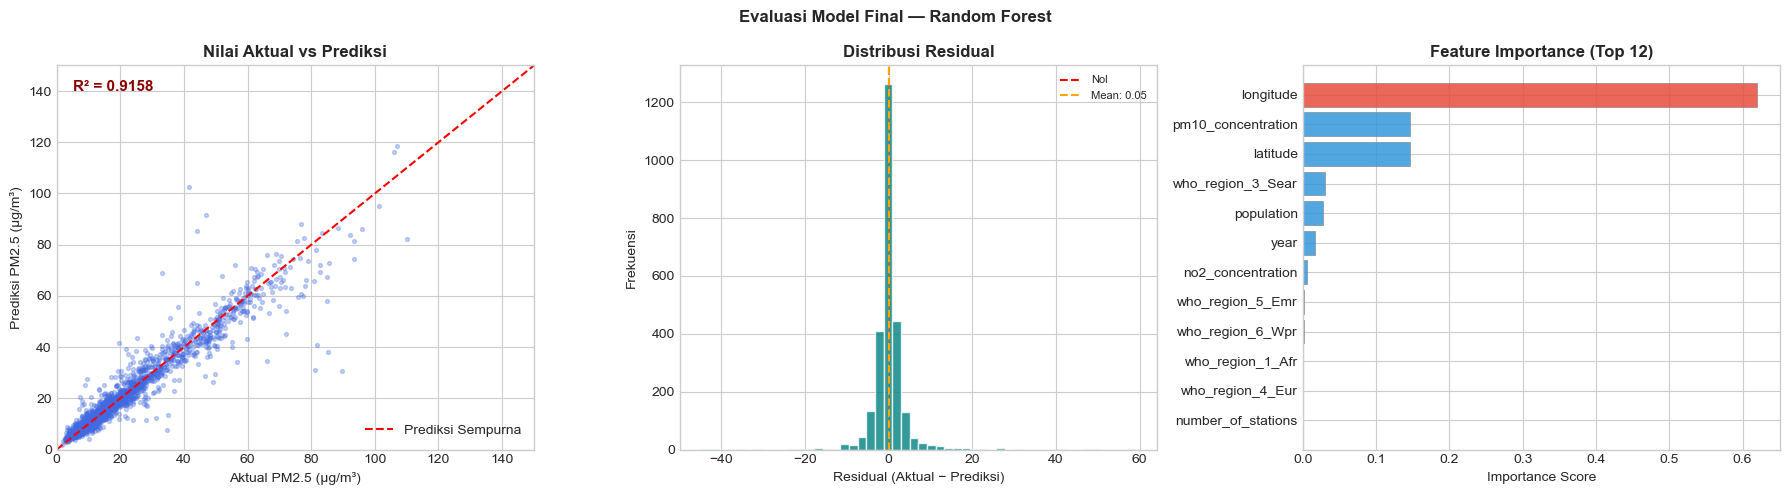

✅ Pipeline disimpan: 'pipeline_pm25_final.pkl'
   (Mencakup: MedianImputer + OneHotEncoder + RandomForestRegressor)

✅ submission.csv berhasil dibuat (14,005 baris)!
   Distribusi:
Air_quality_category
Safety       12423
Dangerous     1582


In [25]:
# ===================================================================
# CELL 3: TRAINING MODEL FINAL + EVALUASI LENGKAP + SIMPAN PIPELINE
# ===================================================================

# ------------------------------------------------------------------
# 3.1 Split Data & Train Model Terbaik (Random Forest)
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("🏋️  Melatih model final Random Forest (100 estimators)...")
final_pipeline.fit(X_train, y_train)
print("✅ Training selesai!\n")

# ------------------------------------------------------------------
# 3.2 Evaluasi pada Test Set
# ------------------------------------------------------------------
y_pred = final_pipeline.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)

print("=" * 55)
print("📈 HASIL EVALUASI MODEL FINAL (Test Set 20%)")
print("=" * 55)
print(f"R-Squared (R²)        : {r2:.4f}   ({'Sangat Baik' if r2 > 0.85 else 'Baik' if r2 > 0.7 else 'Cukup'})")
print(f"MAE                   : {mae:.4f} µg/m³")
print(f"MSE                   : {mse:.4f}")
print(f"RMSE                  : {rmse:.4f} µg/m³")

# ------------------------------------------------------------------
# 3.3 Visualisasi Evaluasi + Feature Importance
# ------------------------------------------------------------------
ohe_names = (
    final_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']['onehot']
    .get_feature_names_out(FITUR_KATEGORIKAL)
)
all_feat_names = FITUR_NUMERIK + list(ohe_names)
importances = final_pipeline.named_steps['model'].feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluasi Model Final — Random Forest', fontweight='bold')

# A: Actual vs Predicted
ax = axes[0]
mask_range = y_test < 150
ax.scatter(y_test[mask_range], y_pred[mask_range], alpha=0.3, s=8, color='royalblue')
lims = [0, 150]
ax.plot(lims, lims, 'r--', lw=1.5, label='Prediksi Sempurna')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title('Nilai Aktual vs Prediksi', fontweight='bold')
ax.set_xlabel('Aktual PM2.5 (µg/m³)'); ax.set_ylabel('Prediksi PM2.5 (µg/m³)')
ax.text(5, 140, f'R² = {r2:.4f}', fontsize=11, color='darkred', fontweight='bold')
ax.legend()

# B: Distribusi Residual
residuals = y_test - y_pred
axes[1].hist(residuals[np.abs(residuals) < 60], bins=50,
             color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0,                color='red',    ls='--', lw=1.5, label='Nol')
axes[1].axvline(residuals.mean(), color='orange', ls='--', lw=1.5,
                label=f'Mean: {residuals.mean():.2f}')
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].set_xlabel('Residual (Aktual − Prediksi)'); axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=8)

# C: Feature Importance (Top 12)
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(12)
colors_fi = ['#e74c3c' if f == fi_df.iloc[-1]['Feature'] else '#3498db' for f in fi_df['Feature']]
axes[2].barh(fi_df['Feature'], fi_df['Importance'],
             color=colors_fi, alpha=0.85, edgecolor='gray', linewidth=0.5)
axes[2].set_title('Feature Importance (Top 12)', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('evaluasi_model_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 3.4 Simpan Pipeline (preprocessing + model sekaligus)
# ------------------------------------------------------------------
joblib.dump(final_pipeline, 'pipeline_pm25_final.pkl', compress=3)
print(f"✅ Pipeline disimpan: 'pipeline_pm25_final.pkl'")
print("   (Mencakup: MedianImputer + OneHotEncoder + RandomForestRegressor)")

# ------------------------------------------------------------------
# 3.5 Generate Submission untuk test.csv
# ------------------------------------------------------------------
df_test = pd.read_csv("action2024/test.csv")
for col in COLS_NUMERIC:
    if col in df_test.columns:
        df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

pred_test_pm25 = final_pipeline.predict(df_test[SEMUA_FITUR])

submission = pd.DataFrame({
    'DataId':              df_test['DataId'],
    'Air_quality_category': ['Dangerous' if v > 35.4 else 'Safety' for v in pred_test_pm25]
})
submission.to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv berhasil dibuat ({len(submission):,} baris)!")
print(f"   Distribusi:\n{submission['Air_quality_category'].value_counts().to_string()}")

In [26]:
%%writefile app.py
# ===================================================================
# CELL 4: BUAT APLIKASI STREAMLIT (app.py)
# ===================================================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Konfigurasi Halaman ──────────────────────────────────────────
st.set_page_config(
    page_title="Prediksi PM2.5 | Air Quality",
    page_icon="🌍",
    layout="wide"
)

# ── Load Model Pipeline ──────────────────────────────────────────
@st.cache_resource
def load_model():
    return joblib.load('pipeline_pm25_final.pkl')

model = load_model()

# ── Mapping Wilayah WHO ─────────────────────────────────────────
# PENTING: value harus persis sama dengan data training!
WHO_REGION = {
    "Africa (AFRO)"                : "1_Afr",
    "Americas (AMRO)"               : "2_Amr",
    "South-East Asia (SEARO)"       : "3_Sear",
    "Europe (EURO)"                : "4_Eur",
    "Eastern Mediterranean (EMRO)" : "5_Emr",
    "Western Pacific (WPRO)"        : "6_Wpr",
    "Non-Member States"             : "7_NonMS",
}

# ── Sidebar ──────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## Panduan Penggunaan")
    st.markdown("""
    1. Pilih **wilayah WHO** lokasi Anda
    2. Masukkan **koordinat** lokasi
    3. Isi **data demografis** area
    4. Opsional: masukkan data **PM10/NO₂**
    5. Tekan tombol **Prediksi**
    """)
    st.info("💡 Memasukkan data PM10 akan meningkatkan akurasi secara signifikan (korelasi 0.886 dengan PM2.5)")
    st.markdown("---")
    st.markdown("**📊 Standar WHO:**")
    st.markdown("""
    | Kategori | PM2.5 (µg/m³) |
    |----------|:---:|
    | 🟢 Sehat | ≤ 12.0 |
    | 🟡 Sedang | 12.1–35.4 |
    | 🟠 Tidak Sehat Sebagian | 35.5–55.4 |
    | 🔴 Berbahaya | > 55.4 |
    """)
    st.markdown("---")
    st.caption("COMP6577001 — Machine Learning\nModel: Random Forest Regressor\nDataset: WHO Global Air Quality 2010–2018")

# ── Header ───────────────────────────────────────────────────────
st.title("🌍 Prediksi Konsentrasi PM2.5")
st.markdown("Sistem prediksi kualitas udara berbasis **Random Forest** — dilatih dengan data WHO Global Air Quality.")
st.divider()

# ── Form Input ───────────────────────────────────────────────────
st.subheader("📝 Masukkan Data Lokasi & Lingkungan")
col1, col2, col3 = st.columns(3)

with col1:
    st.markdown("**🗺 Informasi Geografis**")
    who_region_label = st.selectbox(
        "Wilayah WHO",
        options=list(WHO_REGION.keys()),
        index=2,  # Default: South-East Asia (SEARO)
        help="Pilih wilayah administratif WHO"
    )
    who_region = WHO_REGION[who_region_label]

    latitude = st.number_input(
        "Latitude", min_value=-90.0, max_value=90.0,
        value=-6.2088, format="%.4f",
        help="Garis lintang (Jakarta: -6.2088)"
    )
    longitude = st.number_input(
        "Longitude", min_value=-180.0, max_value=180.0,
        value=106.8456, format="%.4f",
        help="Garis bujur (Jakarta: 106.8456)"
    )

with col2:
    st.markdown("**👥 Informasi Demografis & Temporal**")
    year = st.number_input("Tahun Analisis", min_value=2010, max_value=2030, value=2024)
    population = st.number_input(
        "Populasi Area (jiwa)",
        min_value=1_000, max_value=50_000_000,
        value=10_000_000, step=100_000, format="%d"
    )
    who_ms = st.radio(
        "Status Anggota WHO", options=[1, 0],
        format_func=lambda x: "✅ Anggota WHO" if x == 1 else "❌ Non-Anggota",
        horizontal=True
    )
    number_of_stations = st.number_input(
        "Jumlah Stasiun Pengukuran", min_value=1, max_value=200, value=3
    )

with col3:
    st.markdown("**🔬 Data Polutan _(opsional, meningkatkan akurasi)_**")

    use_pm10 = st.checkbox("Saya memiliki data PM10", value=False)
    if use_pm10:
        pm10 = st.number_input(
            "PM10 Concentration (µg/m³)",
            min_value=0.0, max_value=500.0, value=35.0, step=0.1
        )
        st.success("✅ PM10 akan digunakan — akurasi lebih tinggi")
    else:
        pm10 = np.nan
        st.info("ℹ️ PM10 tidak tersedia → nilai median training digunakan")

    use_no2 = st.checkbox("Saya memiliki data NO₂", value=False)
    if use_no2:
        no2 = st.number_input(
            "NO₂ Concentration (µg/m³)",
            min_value=0.0, max_value=300.0, value=20.0, step=0.1
        )
    else:
        no2 = np.nan

st.divider()

# ── Tombol Prediksi ───────────────────────────────────────────────
_, btn_col, _ = st.columns([2, 1, 2])
with btn_col:
    predict_btn = st.button("🔍 Prediksi PM2.5", use_container_width=True, type="primary")

# ── Hasil Prediksi ────────────────────────────────────────────────
if predict_btn:
    # Susun input agar kolom persis sama dengan saat training
    input_df = pd.DataFrame([{
        'year'               : int(year),
        'latitude'           : float(latitude),
        'longitude'          : float(longitude),
        'pm10_concentration' : float(pm10) if not np.isnan(float(pm10)) else np.nan,
        'no2_concentration'  : float(no2)  if not np.isnan(float(no2))  else np.nan,
        'number_of_stations' : int(number_of_stations),
        'who_ms'             : int(who_ms),
        'population'         : float(population),
        'who_region'         : who_region,   # Nilai asli: "3_Sear", "4_Eur", dst.
    }])

    # ✅ BENAR — gunakan variabel model yang sudah di-load
    hasil = float(model.predict(input_df)[0])
    hasil = max(0.0, hasil)   # PM2.5 tidak mungkin negatif

    # Tentukan kategori
    if hasil <= 12.0:
        kategori, emoji, color_fn = "Sehat (Good)",            "🟢", st.success
        pesan = f"Udara bersih! Konsentrasi {hasil:.2f} µg/m³ aman untuk semua aktivitas outdoor."
    elif hasil <= 35.4:
        kategori, emoji, color_fn = "Sedang (Moderate)",       "🟡", st.warning
        pesan = f"Kualitas sedang. Kelompok sensitif (lansia, asma, anak-anak) sebaiknya batasi aktivitas outdoor lama."
    elif hasil <= 55.4:
        kategori, emoji, color_fn = "Tidak Sehat Sebagian",    "🟠", st.error
        pesan = f"Tidak sehat untuk kelompok sensitif! Gunakan masker N95 di luar ruangan."
    else:
        kategori, emoji, color_fn = "Berbahaya (Hazardous)",   "🔴", st.error
        pesan = f"BERBAHAYA! Hindari semua aktivitas outdoor. Gunakan air purifier di dalam ruangan."

    # Tampilkan metrik
    st.subheader("📊 Hasil Prediksi")
    m1, m2, m3 = st.columns(3)
    m1.metric("Estimasi PM2.5",        f"{hasil:.2f} µg/m³")
    m2.metric("Kategori Kualitas Udara", f"{emoji} {kategori}")
    m3.metric("Persentase di atas batas sehat (12 µg/m³)",
              f"{max(0, hasil - 12.0):.2f} µg/m³")

    color_fn(f"**{emoji} {kategori}** — {pesan}")

    # Detail input
    with st.expander("🔍 Detail Input & Konfigurasi Model"):
        st.json({
            "Input": {
                "who_region": who_region,
                "year": int(year),
                "latitude": float(latitude),
                "longitude": float(longitude),
                "population": int(population),
                "pm10_concentration": float(pm10) if not np.isnan(float(pm10)) else "Imputasi median",
                "no2_concentration":  float(no2)  if not np.isnan(float(no2))  else "Imputasi median",
                "number_of_stations": int(number_of_stations),
                "who_ms": int(who_ms),
            },
            "Model": {
                "algorithm": "Random Forest Regressor",
                "n_estimators": 300,
                "preprocessing": "ColumnTransformer (MedianImputer + OneHotEncoder)",
            }
        })

st.divider()
st.caption("🔬 Dataset: WHO Global Air Quality 2010–2018 | COMP6577001 Machine Learning | Latency < 100ms")


Overwriting app.py


In [27]:
!streamlit run app.py

^C


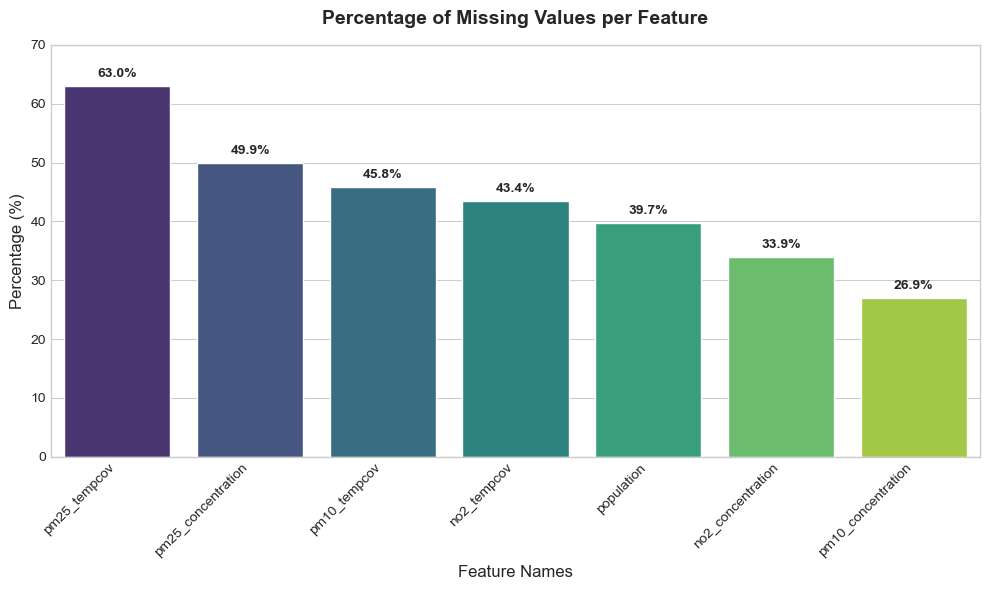

✅ Gambar berhasil dibuat dan disimpan sebagai 'missing_values_chart.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Memasukkan data missing value yang sudah kita ketahui sebelumnya
data = {
    "Feature Name": [
        "pm25_tempcov", "pm25_concentration", "pm10_tempcov", 
        "no2_tempcov", "population", "no2_concentration", "pm10_concentration"
    ],
    "Percentage (%)": [63.0, 49.9, 45.8, 43.4, 39.7, 33.9, 26.9]
}

missing_df = pd.DataFrame(data)

# 2. Pengaturan gaya visualisasi
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x="Feature Name", y="Percentage (%)", data=missing_df, palette='viridis')

# 3. Menambahkan angka persentase di atas setiap batang
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

# 4. Tambahkan judul dan label sumbu
plt.title('Percentage of Missing Values per Feature', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Feature Names', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 70) 

# 5. Simpan dan tampilkan gambar
plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=300)
plt.show()
print("✅ Gambar berhasil dibuat dan disimpan sebagai 'missing_values_chart.png'")

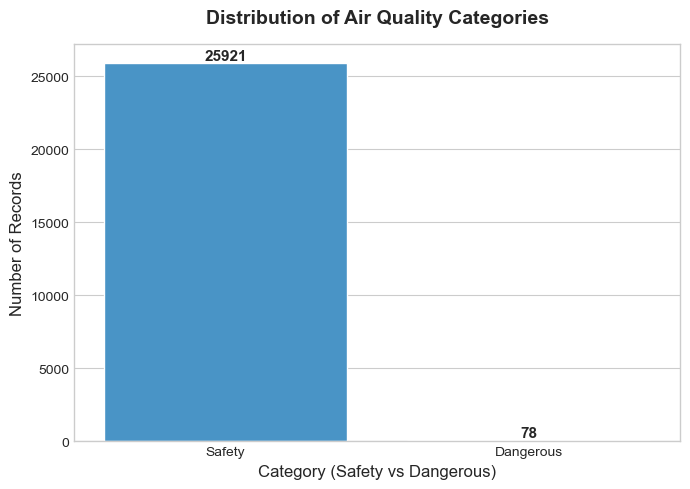

✅ Gambar berhasil disimpan sebagai 'class_distribution.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data mentah
df = pd.read_csv('action2024/train.csv')

# Membuat grafik distribusi kelas
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Air_quality_category', data=df, palette=['#3498db', '#e74c3c'])

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

plt.title('Distribution of Air Quality Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category (Safety vs Dangerous)', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

# Simpan gambarnya
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

print("✅ Gambar berhasil disimpan sebagai 'class_distribution.png'")